# Experiment 3 — Are the three components redundant?

Pure post-hoc analysis of `vib_swag_results.npz` (no training, no TF). The three-way split is *exact*; this asks whether its three axes carry **distinct** information or just co-vary. Three checks:

1. **Correlation matrix** between weight-epistemic / bottleneck / residual across test inputs.
2. **Residual/total ratio per regime** — how much of the "decomposition" is really just (miscalibrated) softmax entropy.
3. **Per-component selective prediction** — does any structured component rank errors better than the residual or the total?

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, pointbiserialr
import os
try:
    open('vib_swag_results.npz')
except FileNotFoundError:
    from google.colab import drive; drive.mount('/content/drive')
    os.chdir('/content/drive/MyDrive/thesis_results')

d = np.load('vib_swag_results.npz', allow_pickle=False)
COMP = ['weight_epistemic', 'bottleneck', 'residual']

def comp_arrays(split):
    if all(f'{c}_{split}' in d.files for c in COMP):
        return {c: d[f'{c}_{split}'] for c in COMP}, d.get(f'total_{split}')
    return None, None

test_comp, total_test = comp_arrays('test')
preds, labels = d['preds_test'], d['labels_test']
correct = preds == labels
print('test inputs:', len(labels), '| splits present:',
      [s for s in ['test', 'svhn', 'cifar10c'] if comp_arrays(s)[0] is not None])

Mounted at /content/drive
test inputs: 10000 | splits present: ['test', 'svhn', 'cifar10c']


### 1. Correlation between components (across test inputs)

Pearson:


,weight_epistemic,bottleneck,residual
weight_epistemic,1.000,0.893,0.904
bottleneck,0.893,1.000,0.868
residual,0.904,0.868,1.000


Spearman:


,weight_epistemic,bottleneck,residual
weight_epistemic,1.000,0.922,0.910
bottleneck,0.922,1.000,0.989
residual,0.910,0.989,1.000


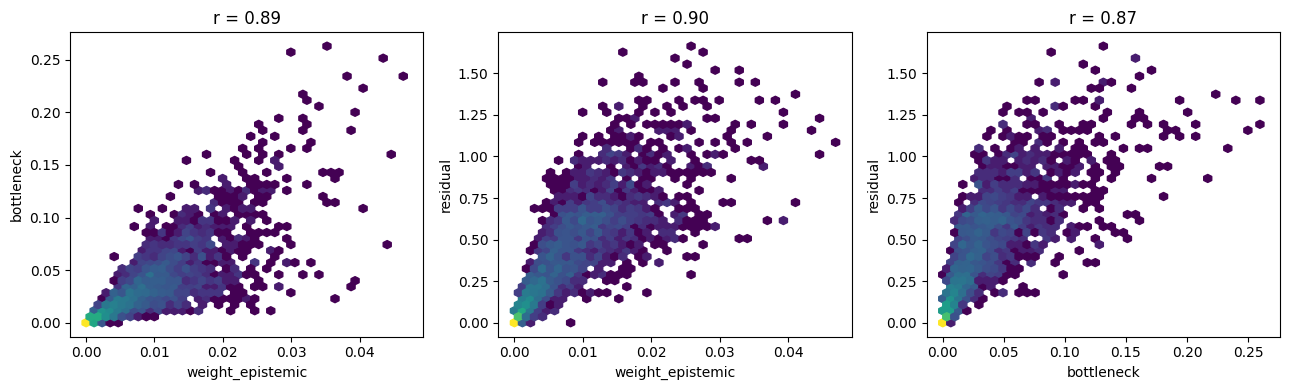

In [2]:
M = np.vstack([test_comp[c] for c in COMP])              # (3, N)
pear = np.corrcoef(M)
spear = np.vstack([[spearmanr(test_comp[a], test_comp[b]).correlation for b in COMP] for a in COMP])

print('Pearson:');  display(pd.DataFrame(pear,  index=COMP, columns=COMP).round(3))
print('Spearman:'); display(pd.DataFrame(spear, index=COMP, columns=COMP).round(3))

fig, ax = plt.subplots(1, 3, figsize=(13, 4))
pairs = [('weight_epistemic', 'bottleneck'),
         ('weight_epistemic', 'residual'),
         ('bottleneck', 'residual')]
for a, (u, v) in zip(ax, pairs):
    a.hexbin(test_comp[u], test_comp[v], gridsize=40, mincnt=1, bins='log')
    a.set_xlabel(u); a.set_ylabel(v)
    a.set_title(f'r = {pearsonr(test_comp[u], test_comp[v])[0]:.2f}')
plt.tight_layout(); plt.savefig('component_correlations.png', dpi=130, bbox_inches='tight'); plt.show()

High correlations (especially Spearman) mean the components rank inputs the same way — i.e. they are one signal split three ways.

### 2. Residual / total share per regime

,weight_epistemic,bottleneck,residual
ID correct,0.018,0.070,0.912
ID incorrect,0.018,0.071,0.911
SVHN,0.015,0.043,0.942
CIFAR-10-C,0.016,0.062,0.922


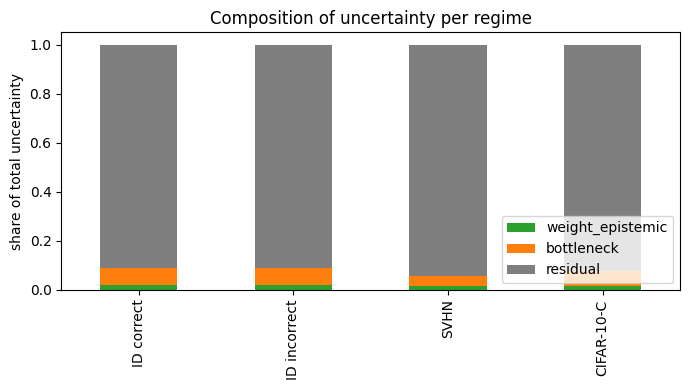

In [3]:
regimes = {'ID correct': {c: test_comp[c][correct] for c in COMP},
           'ID incorrect': {c: test_comp[c][~correct] for c in COMP}}
for split, lbl in [('svhn', 'SVHN'), ('cifar10c', 'CIFAR-10-C')]:
    ca, _ = comp_arrays(split)
    if ca is not None:
        regimes[lbl] = ca

shares = {}
for r, vals in regimes.items():
    tot = sum(vals[c].mean() for c in COMP)
    shares[r] = {c: vals[c].mean() / tot for c in COMP}
shares_df = pd.DataFrame(shares).T[COMP]
display(shares_df.round(3))

ax = shares_df.plot.bar(stacked=True, figsize=(7, 4),
                        color={'weight_epistemic': '#2ca02c', 'bottleneck': '#ff7f0e', 'residual': '#7f7f7f'})
ax.set_ylabel('share of total uncertainty'); ax.set_title('Composition of uncertainty per regime')
ax.legend(loc='lower right'); plt.tight_layout()
plt.savefig('component_shares.png', dpi=130, bbox_inches='tight'); plt.show()

### 3. Per-component selective prediction (does any component rank errors best?)

In [4]:
def aurc_by_score(score, correct):
    # Abstain on the highest-score inputs; lower AURC = better error ranking.
    order = np.argsort(score)                      # ascending uncertainty: keep most certain first
    c = correct[order].astype(float)
    n = len(c)
    risk = 1.0 - np.cumsum(c) / np.arange(1, n + 1)
    cov = np.arange(1, n + 1) / n
    return float(np.trapz(risk, cov))

scores = {**{c: test_comp[c] for c in COMP}, 'total': total_test}
aurc = {name: aurc_by_score(s, correct) for name, s in scores.items()}
pb = {c: pointbiserialr(~correct, test_comp[c]).correlation for c in COMP}   # corr with being wrong

print('AURC by abstention score (lower is better):')
display(pd.Series(aurc).round(4).to_frame('AURC'))
print('Point-biserial corr with misclassification (higher = better error detector):')
display(pd.Series(pb).round(3).to_frame('corr(component, is_wrong)'))

AURC by abstention score (lower is better):


/tmp/ipykernel_594/4034614653.py:8: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risk, cov))


,AURC
weight_epistemic,0.0147
bottleneck,0.0155
residual,0.0140
total,0.0140


Point-biserial corr with misclassification (higher = better error detector):


,"corr(component, is_wrong)"
weight_epistemic,0.463
bottleneck,0.427
residual,0.516


If `residual` (or `total`) matches or beats the structured components on AURC, and the components are highly correlated, the conclusion is clean: the weight-epistemic and bottleneck axes add nothing operationally over the plain residual. That, paired with Experiments 1–2, explains *why* — both stochasticity sources are switched off, so almost all of the "decomposition" is ordinary softmax entropy.